In [9]:
import pandas as pd
import json
import matplotlib.pyplot as plt

In [14]:
similiarity_results = {
    "google/embeddinggemma-300m": [],
     "sentence-transformers/all-MiniLM-L6-v2": [],
     "sentence-transformers/all-MiniLM-L12-v2": [],
     "Qwen/Qwen3-Embedding-0.6B": []

}

with open("gemma_similarities.json", "r", encoding="utf-8") as f:
    similiarity_results['google/embeddinggemma-300m'] = json.load(f)   #json.load() is only for single item file object e.g single array in jsonfile. json.loads(json-string) for json-string

with open("MiniLM_similarities.json", "r", encoding="utf-8") as f:
    similiarity_results["sentence-transformers/all-MiniLM-L6-v2"] = json.load(f)

with open("Qwen3_similarities.json", "r", encoding="utf-8") as f:
    similiarity_results["Qwen/Qwen3-Embedding-0.6B"] = json.load(f)


with open("MiniLM-L12_similarities.json", "r", encoding="utf-8") as f:
    similiarity_results["sentence-transformers/all-MiniLM-L12-v2"] = json.load(f)



print(similiarity_results)
df = pd.DataFrame(similiarity_results)
average_comparison = df.mean()
print(average_comparison)


{'google/embeddinggemma-300m': [0.4895801246166229, 0.6421598196029663, 0.6771937012672424, 0.525954008102417, 0.4811931848526001, 0.5375662446022034, 0.666837751865387, 0.7861030101776123, 0.3630518615245819, 0.49039527773857117, 0.4700677990913391, 0.40297847986221313, 0.49251681566238403, 0.5393823385238647, 0.5850706100463867, 0.5247461199760437, 0.6073281168937683, 0.5038617253303528, 0.5972719788551331, 0.5276960134506226, 0.5496826171875, 0.49833089113235474, 0.38210153579711914, 0.5592032670974731, 0.6609416604042053, 0.3174976110458374, 0.42471981048583984, 0.45006507635116577, 0.49009883403778076, 0.5419004559516907, 0.5151276588439941, 0.5624775290489197, 0.42286550998687744, 0.41285279393196106, 0.5700399279594421, 0.4374171495437622, 0.459807813167572, 0.5784420967102051, 0.377636194229126, 0.5091342926025391, 0.43887221813201904, 0.45489299297332764, 0.41707199811935425, 0.5290142297744751, 0.36438459157943726, 0.5963760614395142, 0.30723729729652405, 0.7227833271026611, 

(array([0, 1, 2, 3]),
 [Text(0, 0, 'google/embeddinggemma-300m'),
  Text(1, 0, 'sentence-transformers/all-MiniLM-L6-v2'),
  Text(2, 0, 'sentence-transformers/all-MiniLM-L12-v2'),
  Text(3, 0, 'Qwen/Qwen3-Embedding-0.6B')])

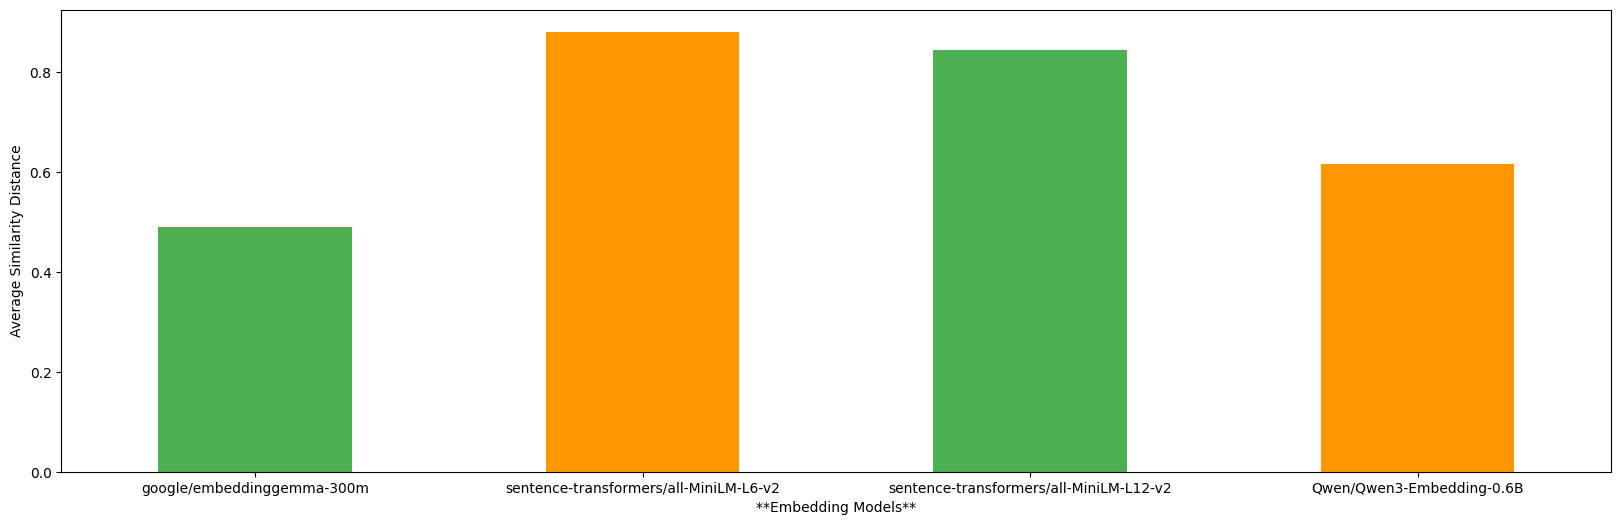

In [16]:

plt.figure(figsize=(20,6))
average_comparison.plot(kind='bar', color=['#4CAF50', '#FF9800'])
plt.ylabel('Average Similarity Distance')
plt.xlabel('**Embedding Models**')
plt.xticks(rotation=0, ha ='center')

['google/embeddinggemma-300m', 'sentence-transformers/all-MiniLM-L12-v2 ', 'sentence-transformers/all-MiniLM-L6-v2 ']
[58.96988300001249, 26.944696600025054, 17.09965769998962]
                                       name  perf_time
0                google/embeddinggemma-300m  58.969883
1  sentence-transformers/all-MiniLM-L12-v2   26.944697
2   sentence-transformers/all-MiniLM-L6-v2   17.099658


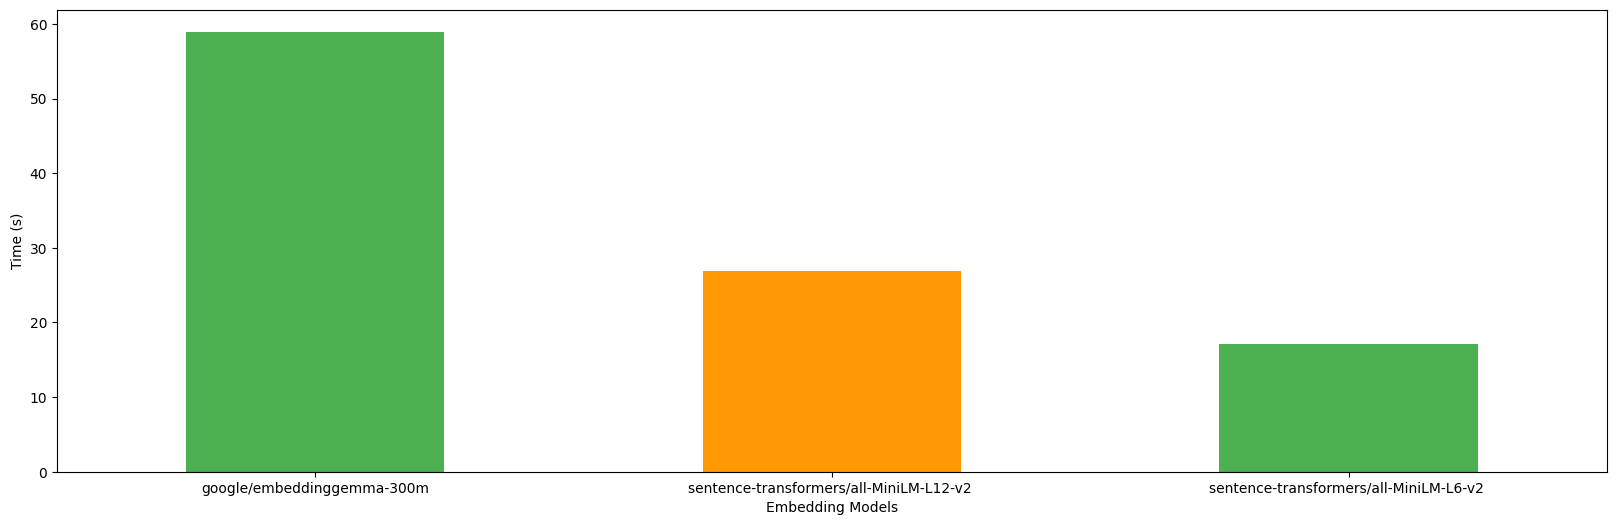

In [45]:
time_results = []
name = []
with open('perf_time.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        result = json.loads(line)
        time_results.append(result['perf_time'])
        name.append(result['name'])
print(name)
print(time_results)


    
time_df = pd.DataFrame({'name': name, 'perf_time': time_results})

print(time_df.head(5))
plt.figure(figsize=(20,6))
time_df.plot(
    kind="bar",
    x='name',
    y='perf_time',
    ax=plt.gca(),
    legend=False,
    color=['#4CAF50', '#FF9800'])

plt.xlabel('Embedding Models')
plt.ylabel('Time (s)')
plt.xticks(rotation=0, ha='center')
plt.show()